# Survival Analysis: Время до оттока платящих пользователей
**Метод:** Kaplan-Meier · Nelson-Aalen · Cox Proportional Hazards
**Бизнес-задача:** Понять *когда* и *почему* уходят пользователи — с поправкой на цензурирование

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Генерация данных

`duration` = дней в продукте, `event` = 1 ушёл / 0 цензурирован (ещё активен)

In [3]:
N = 3_000

plan_config = {
    'basic':      {'n': 1400, 'base_rate': 1/80},
    'pro':        {'n': 1000, 'base_rate': 1/150},
    'enterprise': {'n':  600, 'base_rate': 1/300},
}

records = []
for plan, cfg in plan_config.items():
    n = cfg['n']
    base_rate = cfg['base_rate']
    logins_per_week = np.random.lognormal(1.5, 0.6, n).clip(0.1, 20)
    support_tickets = np.random.poisson(0.4, n)
    nps_score       = np.random.randint(0, 11, n)
    account_age     = np.random.randint(0, 500, n)
    hazard = (
        base_rate
        * np.exp(-0.06 * logins_per_week)
        * np.exp(+0.20 * support_tickets)
        * np.exp(-0.05 * nps_score)
        * np.exp(-0.001 * account_age)
    )
    duration_true = np.random.exponential(1 / hazard)
    duration = np.minimum(duration_true, 365).round(0).astype(int)
    event    = (duration_true <= 365).astype(int)
    for i in range(n):
        records.append({
            'plan': plan, 'duration': duration[i], 'event': event[i],
            'logins_per_week': round(logins_per_week[i], 2),
            'support_tickets': support_tickets[i],
            'nps_score': nps_score[i], 'account_age': account_age[i],
        })

df = pd.DataFrame(records)
df['plan_encoded'] = df['plan'].map({'basic': 0, 'pro': 1, 'enterprise': 2})

print(f'Датасет: {len(df)} пользователей')
print(f'Наблюдаемых оттоков: {df["event"].sum()} ({df["event"].mean():.1%})')
print(f'Цензурированных:     {(1-df["event"]).sum()}')
print(df.groupby('plan').agg(n=('event','count'), churned=('event','sum'),
    churn_rate=('event','mean'), median_duration=('duration','median')).round(2))

Датасет: 3000 пользователей
Наблюдаемых оттоков: 2196 (73.2%)
Цензурированных:     804
               n  churned  churn_rate  median_duration
plan                                                  
basic       1400     1223        0.87            117.0
enterprise   600      274        0.46            365.0
pro         1000      699        0.70            209.0


## 2. Kaplan-Meier: общая кривая и разбивка по тарифам

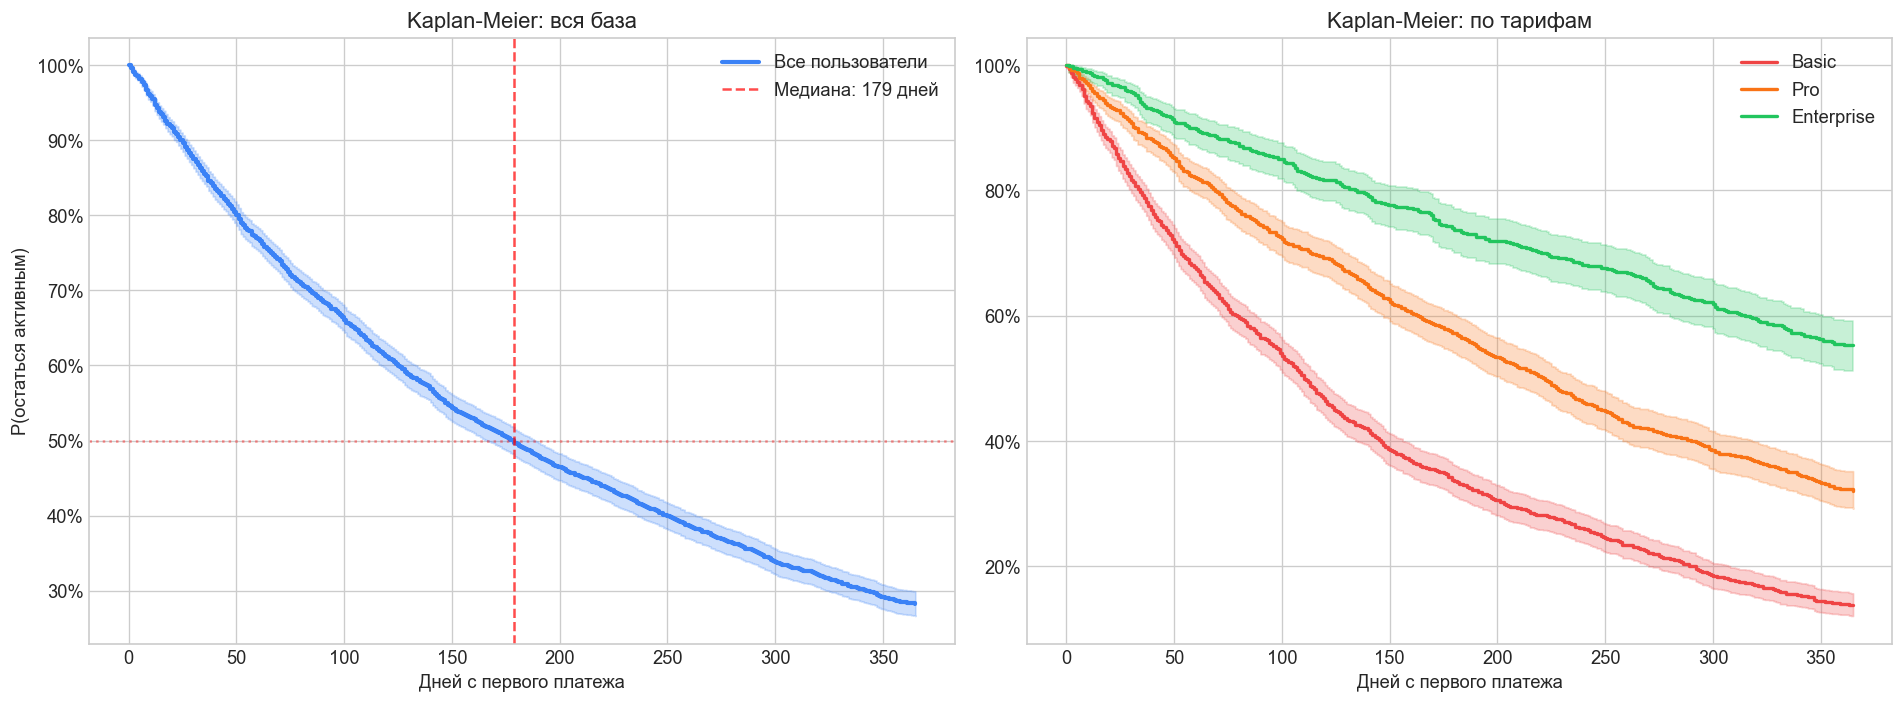

Медианное время до оттока по тарифам:
  Basic        110 дней
  Pro          221 дней
  Enterprise   inf дней


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# общ KM
kmf_all = KaplanMeierFitter()
kmf_all.fit(df['duration'], df['event'], label='Все пользователи')
kmf_all.plot_survival_function(ax=axes[0], ci_show=True, color='#3b82f6', linewidth=2.5)
median_all = kmf_all.median_survival_time_
axes[0].axvline(median_all, color='red', linestyle='--', alpha=0.7,
                label=f'Медиана: {median_all:.0f} дней')
axes[0].axhline(0.5, color='red', linestyle=':', alpha=0.4)
axes[0].set_title('Kaplan-Meier: вся база')
axes[0].set_xlabel('Дней с первого платежа')
axes[0].set_ylabel('P(остаться активным)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

# KM по тарифам
colors = {'basic': '#ef4444', 'pro': '#f97316', 'enterprise': '#22c55e'}
medians = {}
for plan, color in colors.items():
    subset = df[df['plan'] == plan]
    kmf = KaplanMeierFitter()
    kmf.fit(subset['duration'], subset['event'], label=plan.capitalize())
    kmf.plot_survival_function(ax=axes[1], ci_show=True, color=color, linewidth=2)
    medians[plan] = kmf.median_survival_time_
axes[1].set_title('Kaplan-Meier: по тарифам')
axes[1].set_xlabel('Дней с первого платежа')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.savefig('kaplan_meier.png', bbox_inches='tight')
plt.show()

print('Медианное время до оттока по тарифам:')
for plan, med in medians.items():
    print(f'  {plan.capitalize():12} {med:.0f} дней')

## 3. Log-rank test: статистически значимы ли различия?

In [4]:
pairs = [('basic', 'pro'), ('basic', 'enterprise'), ('pro', 'enterprise')]
print('Log-rank test (попарно):')
print('-' * 55)
for g1, g2 in pairs:
    d1 = df[df['plan'] == g1]
    d2 = df[df['plan'] == g2]
    result = logrank_test(d1['duration'], d2['duration'],
                          event_observed_A=d1['event'], event_observed_B=d2['event'])
    sig = 'Значимо' if result.p_value < 0.05 else 'Незначимо'
    print(f'  {g1.capitalize()} vs {g2.capitalize()}: p={result.p_value:.4f}  {sig}')

mv = multivariate_logrank_test(df['duration'], df['plan'], df['event'])
print(f'\nMultivariate log-rank (все 3): p={mv.p_value:.6f}')
if mv.p_value < 0.05:
    print('Retention статистически значимо отличается между тарифами.')

Log-rank test (попарно):
-------------------------------------------------------
  Basic vs Pro: p=0.0000  Значимо
  Basic vs Enterprise: p=0.0000  Значимо
  Pro vs Enterprise: p=0.0000  Значимо

Multivariate log-rank (все 3): p=0.000000
Retention статистически значимо отличается между тарифами.


## 4. Cox Proportional Hazards: что влияет на скорость оттока?

In [7]:
cox_features = ['duration', 'event', 'plan_encoded',
                'logins_per_week', 'support_tickets', 'nps_score', 'account_age']
cox_df = df[cox_features].copy()

cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_df, duration_col='duration', event_col='event')
cph.print_summary(model='cox regression', decimals=3)

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.01
l1 ratio,0.0
baseline estimation,breslow
number of observations,3000
number of events observed,2196
partial log-likelihood,-16119.173
time fit was run,2026-05-11 11:26:55 UTC
model,cox regression


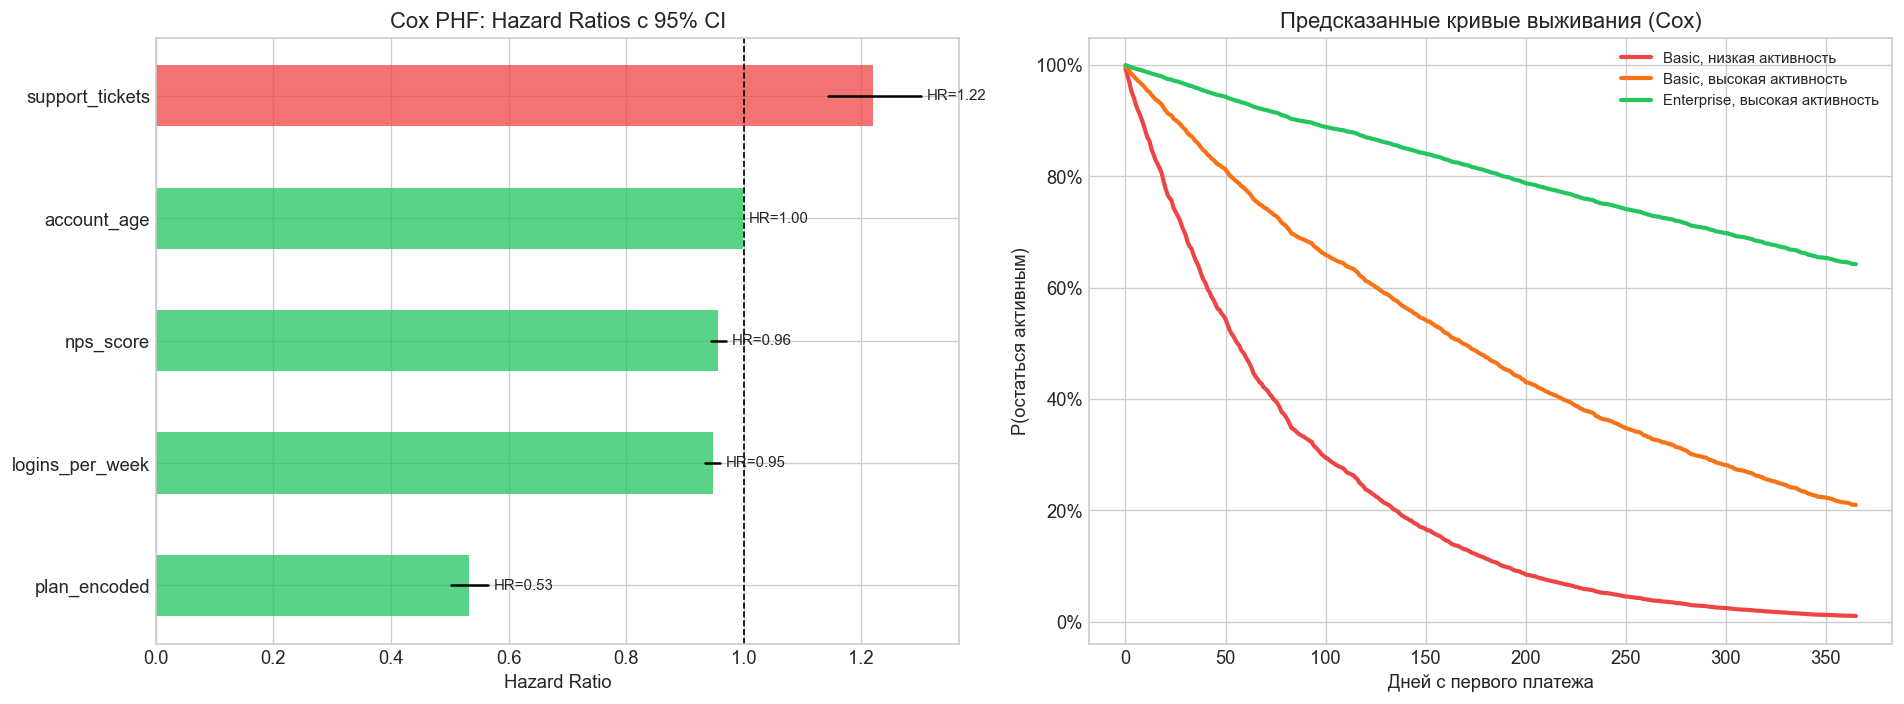

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Forest plot
summary = cph.summary.copy()
summary = summary.sort_values('exp(coef)')
labels = summary.index.tolist()
hr     = summary['exp(coef)'].values
ci_lo  = summary['exp(coef) lower 95%'].values
ci_hi  = summary['exp(coef) upper 95%'].values
y_pos  = range(len(labels))

clrs = ['#ef4444' if h > 1 else '#22c55e' for h in hr]
axes[0].barh(list(y_pos), hr, color=clrs, alpha=0.75, height=0.5)
for i, (lo, hi) in enumerate(zip(ci_lo, ci_hi)):
    axes[0].plot([lo, hi], [i, i], color='black', linewidth=1.5)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('Hazard Ratio')
axes[0].set_title('Cox PHF: Hazard Ratios с 95% CI')
for i, (h, lo, hi) in enumerate(zip(hr, ci_lo, ci_hi)):
    axes[0].text(max(hi, h) + 0.01, i, f'HR={h:.2f}', va='center', fontsize=9)

# Predicted survival curves
profiles = pd.DataFrame({
    'plan_encoded':    [0, 0, 2],
    'logins_per_week': [2, 8, 8],
    'support_tickets': [2, 0, 0],
    'nps_score':       [5, 9, 9],
    'account_age':     [30, 200, 200],
})
pnames = ['Basic, низкая активность', 'Basic, высокая активность', 'Enterprise, высокая активность']
pcolors = ['#ef4444', '#f97316', '#22c55e']
for i, (_, row) in enumerate(profiles.iterrows()):
    sf = cph.predict_survival_function(row.to_frame().T)
    axes[1].plot(sf.index, sf.values.flatten(), label=pnames[i], color=pcolors[i], linewidth=2.5)
axes[1].set_title('Предсказанные кривые выживания (Cox)')
axes[1].set_xlabel('Дней с первого платежа')
axes[1].set_ylabel('P(остаться активным)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('cox_results.png', bbox_inches='tight')
plt.show()

## 5. Бизнес-интерпретация

In [10]:
interpretations = [
    ('logins_per_week', 'Активность (логины/нед)',  'Снижеает риск', 'Активировать через push/email; цель — 5+ логинов/нед'),
    ('support_tickets', 'Тикеты в поддержку',       'Повышает риск', 'Пользователи 2+ тикетами — приоритет retention-кампании'),
    ('nps_score',       'NPS Score',                'Снижеает риск', 'NPS — leading indicator; отслеживать как guardrail-метрику'),
    ('plan_encoded',    'Тариф (Basic→Enterprise)', 'Снижеает риск', 'Upsell Basic→Pro снижает churn hazard значимо'),
    ('account_age',     'Зрелость аккаунта',        'Снижеает риск', 'Первые 60 дней — критическое окно: максимум онбординга'),
]

print('=' * 65)
print('БИЗНЕС-ИНТЕРПРЕТАЦИЯ HAZARD RATIOS')
print('=' * 65)
for feat, name, direction, action in interpretations:
    if feat in cph.summary.index:
        hr_val = cph.summary.loc[feat, 'exp(coef)']
        pval   = cph.summary.loc[feat, 'p']
        sig    = 'Значимо ' if pval < 0.05 else 'Не значимо '
        print(f'\n{sig} | {name}  |  HR={hr_val:.3f}  |  {direction}')
        print(f'   Действие: {action}')

print('\n' + '=' * 65)
print('ГЛАВНЫЙ ВЫВОД:')
print('  Критическое окно удержания — первые 60 дней после первого платежа.')
print('  Пользователи <3 логинов/нед + 2+ тикетов — группа высокого риска.')
print('  Рекомендация: автоматический триггер ретенционного оффера при')  
print('  снижении logins_per_week < 3 в первые 30 дней.')

БИЗНЕС-ИНТЕРПРЕТАЦИЯ HAZARD RATIOS

Значимо  | Активность (логины/нед)  |  HR=0.947  |  Снижеает риск
   Действие: Активировать через push/email; цель — 5+ логинов/нед

Значимо  | Тикеты в поддержку  |  HR=1.221  |  Повышает риск
   Действие: Пользователи 2+ тикетами — приоритет retention-кампании

Значимо  | NPS Score  |  HR=0.957  |  Снижеает риск
   Действие: NPS — leading indicator; отслеживать как guardrail-метрику

Значимо  | Тариф (Basic→Enterprise)  |  HR=0.533  |  Снижеает риск
   Действие: Upsell Basic→Pro снижает churn hazard значимо

Значимо  | Зрелость аккаунта  |  HR=0.999  |  Снижеает риск
   Действие: Первые 60 дней — критическое окно: максимум онбординга

ГЛАВНЫЙ ВЫВОД:
  Критическое окно удержания — первые 60 дней после первого платежа.
  Пользователи <3 логинов/нед + 2+ тикетов — группа высокого риска.
  Рекомендация: автоматический триггер ретенционного оффера при
  снижении logins_per_week < 3 в первые 30 дней.
